# Chương 4 - Minh họa Classification và Regression bằng Keras

Notebook này minh họa các nội dung:

1. Phân loại nhị phân với IMDB  
2. Phân loại đa lớp với Reuters  
3. Hồi quy với Boston Housing  

Mục tiêu:
- Hiểu cách tiền xử lý dữ liệu cho từng bài toán
- Hiểu cách chọn output layer, activation, loss và metric phù hợp
- Quan sát hiện tượng overfitting qua validation
- Minh họa cách dự đoán trên dữ liệu mới

## Import thư viện

In [1]:
# Import các thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt

# Import Keras và các dataset mẫu
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb, reuters, boston_housing
from tensorflow.keras.utils import to_categorical

# Thiết lập để kết quả có thể lặp lại tương đối
np.random.seed(42)

2026-04-16 15:18:14.112637: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 15:18:14.225240: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-16 15:18:15.775408: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


---
# Phần 1 - Phân loại nhị phân với IMDB

Bài toán: dự đoán một review phim là **tích cực** hay **tiêu cực**.

- Input: review phim đã được mã hóa thành chuỗi số nguyên
- Output: 0 hoặc 1 (0 = negative, 1 = positive)
- Loại bài toán: **Binary Classification**

## 1.1 Nạp dữ liệu IMDB

In [2]:
# Chỉ giữ lại 10,000 từ xuất hiện thường xuyên nhất
num_words = 10000

# Nạp dữ liệu IMDB
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

# In thông tin cơ bản về dữ liệu
print('Số mẫu train:', len(train_data))
print('Số mẫu test :', len(test_data))
print('Ví dụ review đầu tiên (dạng số nguyên):', train_data[0][:20])
print('Nhãn của review đầu tiên:', train_labels[0])

Số mẫu train: 25000
Số mẫu test : 25000
Ví dụ review đầu tiên (dạng số nguyên): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Nhãn của review đầu tiên: 1


## 1.2 Vector hóa dữ liệu

Mỗi review sẽ được biến thành một vector nhị phân kích thước 10,000.

- Nếu từ thứ `i` xuất hiện trong review -> vị trí `i = 1`
- Nếu không xuất hiện -> vị trí `i = 0`

Đây là cách biểu diễn **multi-hot encoding**.

In [3]:
# Hàm vector hóa danh sách sequence thành ma trận nhị phân
def vectorize_sequences(sequences, dimension=10000):
    # Tạo ma trận toàn số 0 với shape = (số mẫu, số chiều từ vựng)
    results = np.zeros((len(sequences), dimension))
    
    # Với mỗi mẫu, đánh dấu các vị trí từ xuất hiện bằng 1
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    
    return results

# Vector hóa tập train và test
x_train = vectorize_sequences(train_data, num_words)
x_test = vectorize_sequences(test_data, num_words)

# Chuyển nhãn sang float32 để tiện huấn luyện
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

print('Shape x_train:', x_train.shape)
print('Shape x_test :', x_test.shape)
print('5 phần tử đầu của y_train:', y_train[:5])

Shape x_train: (25000, 10000)
Shape x_test : (25000, 10000)
5 phần tử đầu của y_train: [1. 0. 0. 1. 0.]


## 1.3 Xây dựng mô hình cho binary classification

Cấu hình mô hình:
- Dense(16, relu)
- Dense(16, relu)
- Dense(1, sigmoid)

Giải thích:
- `relu` giúp mô hình học đặc trưng phi tuyến
- `sigmoid` cho đầu ra là xác suất thuộc lớp positive

In [4]:
# Tạo mô hình tuần tự cho bài toán phân loại nhị phân
imdb_model = keras.Sequential([    
    # layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile mô hình
# - binary_crossentropy phù hợp cho binary classification
# - accuracy dùng để theo dõi tỉ lệ dự đoán đúng
imdb_model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Hiển thị kiến trúc mô hình
imdb_model.summary()

I0000 00:00:1776327791.288264   29940 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6203 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 1.4 Tạo validation set

In [ ]:
# Lấy 10,000 mẫu đầu tiên làm validation set
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print('Shape partial_x_train:', partial_x_train.shape)
print('Shape x_val          :', x_val.shape)

Shape partial_x_train: (15000, 10000)
Shape x_val          : (10000, 10000)


## 1.5 Huấn luyện mô hình IMDB

In [6]:
# Huấn luyện mô hình với validation data
history_imdb = imdb_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20


2026-04-16 15:23:22.867650: I external/local_xla/xla/service/service.cc:163] XLA service 0x7626dc008440 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-16 15:23:22.867689: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6
2026-04-16 15:23:22.902916: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 15:23:23.120186: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-04-16 15:23:23.631222: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_289', 8 bytes spill stores, 8 bytes spill loads

2026-04-16 15:23:23.653425: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] p

17/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6340 - loss: 0.6395

I0000 00:00:1776327805.808811   36707 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


28/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6779 - loss: 0.6024

2026-04-16 15:23:27.043580: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 12 bytes spill stores, 12 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6840 - loss: 0.5965

2026-04-16 15:23:30.166931: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 12 bytes spill stores, 12 bytes spill loads



30/30 ━━━━━━━━━━━━━━━━━━━━ 9s 174ms/step - accuracy: 0.7694 - loss: 0.5136 - val_accuracy: 0.8588 - val_loss: 0.3830
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8997 - loss: 0.3035 - val_accuracy: 0.8756 - val_loss: 0.3140
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9279 - loss: 0.2228 - val_accuracy: 0.8767 - val_loss: 0.3046
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9409 - loss: 0.1833 - val_accuracy: 0.8860 - val_loss: 0.2767
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9504 - loss: 0.1518 - val_accuracy: 0.8852 - val_loss: 0.2892
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9595 - loss: 0.1295 - val_accuracy: 0.8863 - val_loss: 0.2884
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9681 - loss: 0.1079 - val_accuracy: 0.8797 - val_loss: 0.3092
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9730 - loss: 0.0938 - val_accuracy: 0.8703 - val_loss: 0

## 1.6 Vẽ đồ thị loss và accuracy

Mục đích: quan sát khi nào mô hình bắt đầu overfit.

**Dấu hiệu overfitting thường thấy:**

- Training loss tiếp tục giảm nhưng Validation loss bắt đầu tăng
- Hoặc Validation accuracy ngừng tăng / giảm

Khi đó mô hình không còn học ra quy luật chung nữa, mà bắt đầu bám quá sát chi tiết và nhiễu của train set.

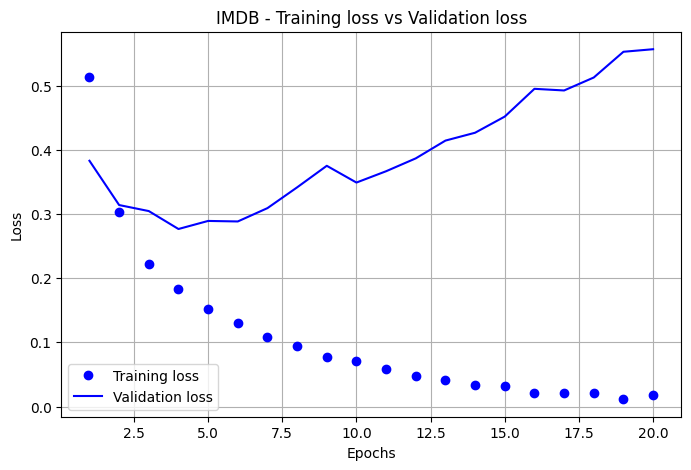

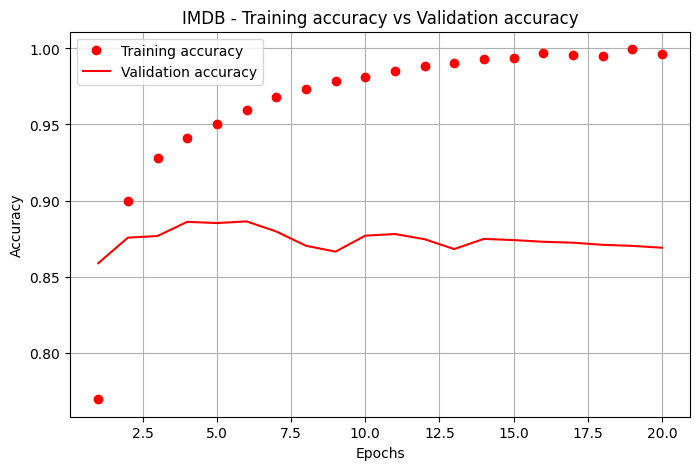

In [7]:
# Lấy lịch sử huấn luyện
history_dict = history_imdb.history

# Trích xuất loss và val_loss
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

# Tạo trục epoch
epochs = range(1, len(loss_values) + 1)

# Vẽ đồ thị loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('IMDB - Training loss vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Trích xuất accuracy và val_accuracy
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

# Vẽ đồ thị accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_values, 'ro', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'r', label='Validation accuracy')
plt.title('IMDB - Training accuracy vs Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 1.7 Huấn luyện lại mô hình với số epoch phù hợp hơn

Khi đã quan sát validation curve, ta thường chọn số epoch trước khi overfitting rõ rệt.

Ở đây minh họa train lại với **4 epochs** để có một mô hình gọn hơn.

In [8]:
# Khởi tạo lại mô hình mới từ đầu
imdb_final_model = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# Compile lại mô hình
imdb_final_model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện trên toàn bộ training set với số epoch ít hơn
imdb_final_model.fit(
    x_train,
    y_train,
    epochs=4,
    batch_size=512,
    verbose=1
)

# Đánh giá trên test set
imdb_results = imdb_final_model.evaluate(x_test, y_test, verbose=0)
print('Test loss    :', imdb_results[0])
print('Test accuracy:', imdb_results[1])

Epoch 1/4
46/49 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7242 - loss: 0.5935

2026-04-16 15:24:07.627132: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 8 bytes spill stores, 8 bytes spill loads

2026-04-16 15:24:07.817729: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 12 bytes spill stores, 12 bytes spill loads



49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 72ms/step - accuracy: 0.8081 - loss: 0.5013
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8960 - loss: 0.2996
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9157 - loss: 0.2306
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9307 - loss: 0.1938


2026-04-16 15:24:13.857103: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 15:24:14.022933: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 15:24:14.089810: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 15:24:14.203307: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 15:24:19.632448: I external/local_xla/xla/str

Test loss    : 0.27983778715133667
Test accuracy: 0.8885200023651123


## 1.8 Dự đoán trên dữ liệu mới

In [9]:
# Dự đoán xác suất cho 5 review đầu tiên của tập test
predictions_imdb = imdb_final_model.predict(x_test[:5])

# In xác suất dự đoán và nhãn thật
for i, pred in enumerate(predictions_imdb):
    print(f'Mẫu {i}: xác suất positive = {pred[0]:.4f}, nhãn thật = {int(y_test[i])}')

2026-04-16 15:24:24.213381: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_9', 8 bytes spill stores, 8 bytes spill loads



1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Mẫu 0: xác suất positive = 0.2244, nhãn thật = 0
Mẫu 1: xác suất positive = 0.9988, nhãn thật = 1
Mẫu 2: xác suất positive = 0.8490, nhãn thật = 1
Mẫu 3: xác suất positive = 0.7358, nhãn thật = 0
Mẫu 4: xác suất positive = 0.9366, nhãn thật = 1


---
# Phần 2 - Phân loại đa lớp với Reuters

Bài toán: phân loại một bản tin ngắn vào **1 trong 46 chủ đề**.

- Input: bản tin đã được mã hóa thành chuỗi số nguyên
- Output: một trong 46 lớp
- Loại bài toán: **Multiclass Classification**

## 2.1 Nạp dữ liệu Reuters

In [10]:
# Nạp dữ liệu Reuters, chỉ giữ 10,000 từ phổ biến nhất
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

# In thông tin cơ bản
print('Số mẫu train:', len(train_data))
print('Số mẫu test :', len(test_data))
print('Số lớp khác nhau trong train:', len(np.unique(train_labels)))
print('20 phần tử đầu tiên của mẫu đầu:', train_data[0][:20])
print('Nhãn của mẫu đầu:', train_labels[0])

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Số mẫu train: 8982
Số mẫu test : 2246
Số lớp khác nhau trong train: 46
20 phần tử đầu tiên của mẫu đầu: [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7]
Nhãn của mẫu đầu: 3


## 2.2 Vector hóa dữ liệu và one-hot nhãn

In [11]:
# Vector hóa dữ liệu đầu vào giống IMDB
x_train = vectorize_sequences(train_data, 10000)
x_test = vectorize_sequences(test_data, 10000)

# One-hot encode nhãn vì đây là bài toán 46 lớp
one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

print('Shape x_train               :', x_train.shape)
print('Shape one_hot_train_labels  :', one_hot_train_labels.shape)
print('Ví dụ one-hot label đầu tiên :', one_hot_train_labels[0])

Shape x_train               : (8982, 10000)
Shape one_hot_train_labels  : (8982, 46)
Ví dụ one-hot label đầu tiên : [0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


## 2.3 Xây dựng mô hình cho multiclass classification

Cấu hình mô hình:
- Dense(64, relu)
- Dense(64, relu)
- Dense(46, softmax)

Giải thích:
- Output có 46 node vì có 46 lớp
- `softmax` tạo phân phối xác suất trên toàn bộ lớp
- `categorical_crossentropy` đo mức sai khác giữa phân phối dự đoán và nhãn thật one-hot

In [12]:
# Tạo mô hình phân loại đa lớp
reuters_model = keras.Sequential([
    # layers.Dense(64, activation='relu', input_shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# Compile mô hình
reuters_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Hiển thị kiến trúc mô hình
reuters_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 2.4 Tạo validation set

In [13]:
# Lấy 1,000 mẫu đầu làm validation set
x_val = x_train[:1000]
partial_x_train = x_train[1000:]

y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

print('Shape partial_x_train:', partial_x_train.shape)
print('Shape x_val          :', x_val.shape)

Shape partial_x_train: (7982, 10000)
Shape x_val          : (1000, 10000)


## 2.5 Huấn luyện mô hình Reuters

In [14]:
# Huấn luyện mô hình với validation set
history_reuters = reuters_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=512,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20


2026-04-16 15:24:56.035439: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:24:56.035485: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:24:56.035506: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:24:56.035528: I external/l

14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3756 - loss: 3.2481

2026-04-16 15:25:02.067598: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:02.067644: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:02.067666: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:02.067687: I external/l

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 514ms/step - accuracy: 0.3906 - loss: 3.1757

2026-04-16 15:25:10.564979: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:10.565032: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:11.077008: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_66', 8 bytes spill stores, 8 bytes spill loads

2026-04-16 15:25:11.898723: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 798ms/step - accuracy: 0.4989 - loss: 2.6523 - val_accuracy: 0.6430 - val_loss: 1.7745
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6896 - loss: 1.5051 - val_accuracy: 0.7030 - val_loss: 1.3552
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7526 - loss: 1.1596 - val_accuracy: 0.7560 - val_loss: 1.1711
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7987 - loss: 0.9518 - val_accuracy: 0.7710 - val_loss: 1.0683
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8267 - loss: 0.7950 - val_accuracy: 0.7860 - val_loss: 0.9973
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8577 - loss: 0.6653 - val_accuracy: 0.8040 - val_loss: 0.9407
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8825 - loss: 0.5529 - val_accuracy: 0.8160 - val_loss: 0.9077
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9020 - loss: 0.4652 - val_accuracy: 0.8190 - val_loss: 

## 2.6 Vẽ đồ thị loss và accuracy của Reuters

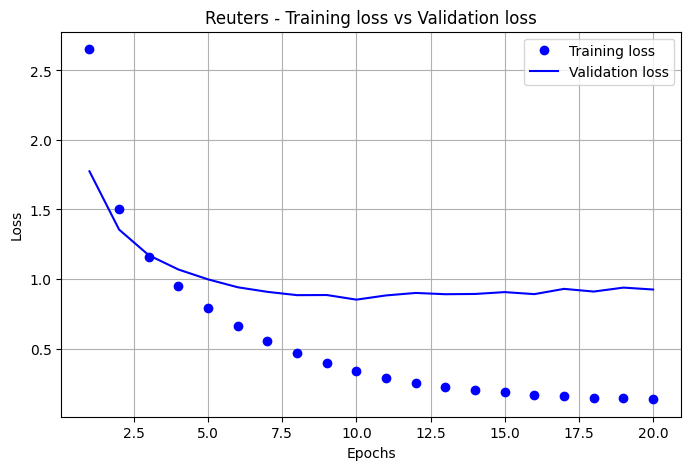

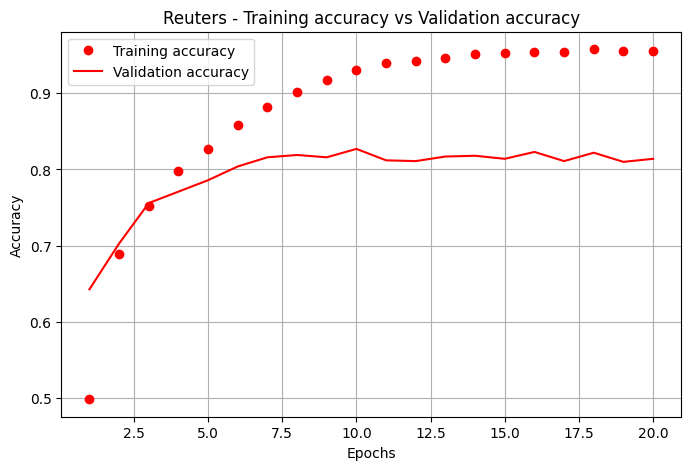

In [15]:
# Lấy lịch sử huấn luyện Reuters
history_dict = history_reuters.history
loss = history_dict['loss']
val_loss = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(loss) + 1)

# Vẽ loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Reuters - Training loss vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, 'ro', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Reuters - Training accuracy vs Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 2.7 Huấn luyện lại mô hình Reuters với số epoch phù hợp hơn

Theo ví dụ sách, validation thường đạt tốt ở khoảng 8-9 epochs. Ở đây minh họa train lại với **9 epochs**.

In [16]:
# Khởi tạo lại mô hình mới
reuters_final_model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# Compile mô hình mới
reuters_final_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Huấn luyện trên toàn bộ train set (không dùng validation)
reuters_final_model.fit(
    x_train,
    one_hot_train_labels,
    epochs=9,
    batch_size=512,
    verbose=1
)

# Đánh giá trên test set
reuters_results = reuters_final_model.evaluate(x_test, one_hot_test_labels, verbose=0)
print('Test loss    :', reuters_results[0])
print('Test accuracy:', reuters_results[1])

Epoch 1/9
14/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3392 - loss: 3.3760

2026-04-16 15:25:33.836872: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:33.836920: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:33.836946: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-16 15:25:33.836972: I external/l

18/18 ━━━━━━━━━━━━━━━━━━━━ 11s 440ms/step - accuracy: 0.4844 - loss: 2.7016
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6828 - loss: 1.4812
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7477 - loss: 1.1384
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7944 - loss: 0.9302
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8309 - loss: 0.7650
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8597 - loss: 0.6379
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8853 - loss: 0.5273
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9061 - loss: 0.4476
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9193 - loss: 0.3780
Test loss    : 0.931324303150177
Test accuracy: 0.7867319583892822


## 2.8 Dự đoán trên dữ liệu mới

In [17]:
# Dự đoán trên 3 mẫu đầu tiên của test set
predictions_reuters = reuters_final_model.predict(x_test[:3])

# In lớp dự đoán và nhãn thật
for i, pred in enumerate(predictions_reuters):
    predicted_class = np.argmax(pred)
    true_class = test_labels[i]
    print(f'Mẫu {i}: lớp dự đoán = {predicted_class}, nhãn thật = {true_class}, xác suất cao nhất = {pred[predicted_class]:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Mẫu 0: lớp dự đoán = 3, nhãn thật = 3, xác suất cao nhất = 0.9886
Mẫu 1: lớp dự đoán = 10, nhãn thật = 10, xác suất cao nhất = 0.7246
Mẫu 2: lớp dự đoán = 1, nhãn thật = 1, xác suất cao nhất = 0.8979


## 2.9 Minh họa cách khác: dùng integer labels với sparse_categorical_crossentropy

In [18]:
# Mô hình minh họa dùng nhãn dạng số nguyên thay vì one-hot
reuters_sparse_model = keras.Sequential([
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# Compile với sparse_categorical_crossentropy
# Dùng khi nhãn vẫn ở dạng số nguyên (0, 1, 2, ...)
reuters_sparse_model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Chỉ train 1 epoch để minh họa cách dùng
reuters_sparse_model.fit(
    x_train,
    np.array(train_labels),
    epochs=1,
    batch_size=512,
    verbose=1
)

18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 140ms/step - accuracy: 0.4487 - loss: 2.8587


---
# Phần 3 - Hồi quy với Boston Housing

Bài toán: dự đoán giá nhà.

- Input: 13 đặc trưng số
- Output: giá nhà trung vị
- Loại bài toán: **Regression**

## 3.1 Nạp dữ liệu Boston Housing

In [19]:
# Nạp dữ liệu Boston Housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

# In thông tin dữ liệu
print('Shape train_data   :', train_data.shape)
print('Shape test_data    :', test_data.shape)
print('Shape train_targets:', train_targets.shape)
print('5 target đầu tiên  :', train_targets[:5])

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
Shape train_data   : (404, 13)
Shape test_data    : (102, 13)
Shape train_targets: (404,)
5 target đầu tiên  : [15.2 42.3 50.  21.1 17.7]


## 3.2 Chuẩn hóa dữ liệu

Vì các đặc trưng có thang đo khác nhau, ta cần chuẩn hóa (theo z-score normalization):

- trừ mean của từng feature
- chia cho standard deviation của từng feature

$$\frac{x-mean}{standard\ deviation}$$

**Giá trị sau chuẩn hóa:**
- Thường xoay quanh 0, có thể âm hoặc dương
- Mean gần 0, std gần 1

Lưu ý: chỉ dùng **mean và std của training set**.

In [20]:
# Tính mean theo từng cột từ training data
mean = train_data.mean(axis=0)
train_data -= mean
test_data -= mean

# Tính std theo từng cột từ training data
std = train_data.std(axis=0) # Tính độ lệch chuẩn của từng cột đặc trưng
train_data /= std
test_data /= std

# In thử mean và std sau chuẩn hóa của tập train
print('Mean gần 0:', train_data.mean(axis=0)[:5])
print('Std gần 1 :', train_data.std(axis=0)[:5])

Mean gần 0: [-1.01541438e-16  1.09923072e-17  1.80933376e-15 -7.80453809e-17
 -5.25047552e-15]
Std gần 1 : [1. 1. 1. 1. 1.]


## 3.3 Hàm xây dựng mô hình regression

In [21]:
# Hàm xây dựng mô hình hồi quy
def build_regression_model():
    # Tạo mô hình tuần tự
    model = keras.Sequential([
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)  # Không dùng activation ở output cho regression
    ])
    
    # Compile mô hình
    # - mse là loss phổ biến cho regression
    # - mae dễ diễn giải hơn vì đo sai lệch trung bình tuyệt đối
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

# Tạo thử mô hình
regression_model = build_regression_model()
regression_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 3.4 K-fold validation

Vì dữ liệu ít, ta dùng K-fold validation để đánh giá ổn định hơn.

In [22]:
# Số fold dùng để cross-validation
k = 4

# Số mẫu trong mỗi fold
num_val_samples = len(train_data) // k

# Số epoch huấn luyện mỗi fold
num_epochs = 100

# Lưu lịch sử MAE theo từng fold
all_mae_histories = []

# Lặp qua từng fold
for i in range(k):
    print(f'Processing fold #{i}')
    
    # Tách validation data cho fold hiện tại
    # fold 0 lấy đoạn từ 0 đến num_val_samples
    # fold 1 lấy đoạn từ num_val_samples đến 2 * num_val_samples
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    
    # Ghép phần còn lại thành partial training data:
    # ghép phần trước và phần sau của validation fold lại với nhau
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0
    )
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0
    )
    
    # Tạo mô hình mới cho mỗi fold
    model = build_regression_model()
    
    # Huấn luyện mô hình và lưu validation MAE
    history = model.fit(
        partial_train_data,
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs,
        batch_size=16,
        verbose=0
    )
    
    # Lưu lịch sử validation MAE của fold này
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

Processing fold #0
Processing fold #1
Processing fold #2
Processing fold #3


## 3.5 Tính trung bình validation MAE theo epoch

Khi theo dõi MAE trên validation theo từng epoch:

- Nếu validation MAE còn giảm → mô hình còn đang cải thiện
- Nếu validation MAE giảm rất chậm hoặc gần như đứng yên → có thể đã đủ epoch
- Nếu validation MAE bắt đầu tăng → có thể mô hình đang overfit

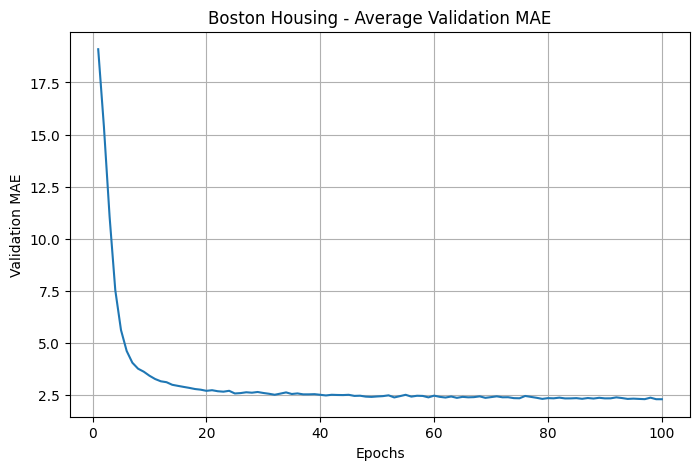

In [23]:
# Tính trung bình MAE theo từng epoch qua tất cả các fold
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

# Vẽ đường cong validation MAE trung bình
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.title('Boston Housing - Average Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.grid(True)
plt.show()

## 3.6 Huấn luyện mô hình cuối cùng

Sau khi xem K-fold validation, ta chọn số epoch phù hợp rồi train lại trên toàn bộ training set.

In [24]:
# Tạo mô hình cuối cùng
final_regression_model = build_regression_model()

# Huấn luyện mô hình cuối cùng trên toàn bộ training set
# Ở đây dùng 80 epochs để minh họa; có thể điều chỉnh tùy theo đường cong MAE ở trên
final_regression_model.fit(
    train_data,
    train_targets,
    epochs=80,
    batch_size=16,
    verbose=1
)

# Đánh giá trên test set
test_mse_score, test_mae_score = final_regression_model.evaluate(test_data, test_targets, verbose=0)
print('Test MSE:', test_mse_score)
print('Test MAE:', test_mae_score)

Epoch 1/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - loss: 505.0358 - mae: 20.6457
Epoch 2/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 332.5476 - mae: 16.1508
Epoch 3/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 162.9519 - mae: 10.2597
Epoch 4/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 74.9462 - mae: 6.3770
Epoch 5/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 49.8249 - mae: 4.9430
Epoch 6/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 38.0487 - mae: 4.2314
Epoch 7/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31.2204 - mae: 3.7292
Epoch 8/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 26.8680 - mae: 3.4598
Epoch 9/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 23.4576 - mae: 3.2592
Epoch 10/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 20.6401 - mae: 3.0238
Epoch 11/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 18.1608 - mae: 2.8003
Epoch 12/80
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 16.4775 - mae: 2.7190
Epoch 13/80
26/26 ━━━━━━━━━━━━

## 3.7 Dự đoán giá nhà trên dữ liệu mới

In [25]:
# Dự đoán trên 5 mẫu đầu tiên của tập test
predictions_boston = final_regression_model.predict(test_data[:5])

# In giá trị dự đoán và giá trị thật
for i in range(5):
    print(f'Mẫu {i}: dự đoán = {predictions_boston[i][0]:.3f}, thực tế = {test_targets[i]:.3f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step
Mẫu 0: dự đoán = 7.964, thực tế = 7.200
Mẫu 1: dự đoán = 18.800, thực tế = 18.800
Mẫu 2: dự đoán = 21.929, thực tế = 19.000
Mẫu 3: dự đoán = 31.099, thực tế = 27.000
Mẫu 4: dự đoán = 25.490, thực tế = 22.200


---
# Tổng kết Chương 4

## So sánh 3 bài toán

| Bài toán | Loại | Output layer | Activation | Loss | Metric |
|---|---|---|---|---|---|
| IMDB | Binary classification | Dense(1) | Sigmoid | binary_crossentropy | accuracy |
| Reuters | Multiclass classification | Dense(46) | Softmax | categorical_crossentropy / sparse_categorical_crossentropy | accuracy |
| Boston Housing | Regression | Dense(1) | Không dùng | mse | mae |

Các ý cần nhớ:
- Binary classification $\rightarrow$ sigmoid + binary_crossentropy
- Multiclass classification $\rightarrow$ softmax + categorical_crossentropy
- Regression $\rightarrow$ output tuyến tính + mse/mae
- Luôn theo dõi validation để phát hiện overfitting
- Dữ liệu ít $\rightarrow$ nên cân nhắc K-fold validation